# MURA X-Ray Classification


## What are we doing?

We have X-ray images of bones (shoulder, elbow, wrist, hand, finger, forearm, humerus) and we want to automatically decide if each image is **normal** or **abnormal**.

This is a **binary classification** problem. The model outputs a number between 0 and 1:
- Close to **0** → the model thinks the X-ray is **normal**
- Close to **1** → the model thinks the X-ray is **abnormal**

## Dataset: MURA

MURA (MUsculoskeletal RAdiographs) was created by Stanford University.
- ~40,000 X-ray images across 7 body parts
- Already split into **train** (~36,800 images) and **validation** (~3,200 images)
- Each image is labeled by a radiologist as normal or abnormal

## Models in this notebook

Models 1 (Custom CNN) and 2 (DenseNet121) are covered by Mike's notebook.  
This notebook focuses on:

| # | Model | Type |
|---|---|---|
| 3 | EfficientNetB0 | Pre-trained on ImageNet, fine-tuned |
| 4 | Dual-Backbone Fusion | MobileNetV2 + EfficientNetB0 in parallel, features fused |

---
## Download the Dataset

In [1]:
import os

# ---------------------------------------------------------------
# OPTION 1 — Running on Kaggle
# Add the dataset via the Data tab (search "mura v11" by JinCui)
# ---------------------------------------------------------------
DATASET_PATH = '/kaggle/input/datasets/cjinny/mura-v11'

# ---------------------------------------------------------------
# OPTION 2 — Running on Colab
# Comment out Option 1 above and run this cell instead
# ---------------------------------------------------------------
# import gdown
# DATASET_PATH = '/content/mura'
# GDRIVE_FILE_ID = '1GW1j9e2KlAZ7fCztft7ubdBRHRvhfPDm'
# if not os.path.exists(f'{DATASET_PATH}/MURA-v1.1'):
#     os.makedirs(DATASET_PATH, exist_ok=True)
#     zip_path = f'{DATASET_PATH}/mura-v11.zip'
#     print('Downloading dataset from Google Drive ...')
#     gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', zip_path, quiet=False)
#     print('Unzipping ...')
#     os.system(f'unzip -q {zip_path} -d {DATASET_PATH}')
#     os.remove(zip_path)
#     print('Done!')
# else:
#     print('Dataset already extracted, skipping download.')

# print('Dataset path exists:', os.path.exists(DATASET_PATH))
# print('Contents:', os.listdir(DATASET_PATH) if os.path.exists(DATASET_PATH) else 'NOT FOUND')

---
## GPU & Mixed Precision Setup

In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

print(tf.config.list_physical_devices('GPU'))

# mixed_float16 uses 16-bit floats on GPU — roughly 2x faster, half the memory
mixed_precision.set_global_policy('mixed_float16')

2026-03-14 15:05:15.954108: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773500715.979490     151 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773500715.987090     151 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773500716.006988     151 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773500716.007021     151 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773500716.007023     151 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import backend as K, mixed_precision
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import (Input, Conv2D, Dense, Dropout, MaxPool2D,
                                      BatchNormalization, GlobalAveragePooling2D,
                                      GRU, TimeDistributed, Masking)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

mixed_precision.set_global_policy('mixed_float16')

%matplotlib inline

IMG_SIZE   = 224   # resize all images to 224x224 pixels
BATCH_SIZE = 64    # larger batch — fits in memory thanks to mixed precision
EPOCHS     = 30    # maximum training epochs (EarlyStopping will stop earlier)
MAX_VIEWS  = 7     # max X-ray views per study (used by CNN-GRU)

print('TensorFlow version:', tf.__version__)
print('Mixed precision policy:', mixed_precision.global_policy().name)

TensorFlow version: 2.19.0
Mixed precision policy: mixed_float16


---
## Load the Data

The MURA dataset comes with CSV files listing every image path and its label.
We read those CSVs and build a single DataFrame with columns: `image_path`, `label_type`, `set_type`, `category`.

In [4]:
def extract_set_category(path):
    pattern = r'.*(?P<set_type>train|valid)/(?P<category>XR_[A-Z]+)/(?P<patient_id>patient\d+)/study.*'
    match = re.match(pattern, path)
    return match.groupdict() if match else None


def load_split(split, dataset_path=DATASET_PATH):
    image_paths = pd.read_csv(f'{dataset_path}/MURA-v1.1/{split}_image_paths.csv',
                              header=None, names=['image_path'])
    image_paths['path'] = image_paths['image_path'].apply(
        lambda x: '/'.join(x.split('/')[:-1]) + '/'
    )
    labels = pd.read_csv(f'{dataset_path}/MURA-v1.1/{split}_labeled_studies.csv',
                         header=None, names=['path', 'label'])
    return labels.merge(image_paths, on='path', how='left')


df = pd.concat([load_split('train'), load_split('valid')]).reset_index(drop=True)
df = pd.concat([df, pd.DataFrame(df['path'].apply(extract_set_category).tolist())], axis=1)
df['label_type'] = df['label'].map({1: 'abnormal', 0: 'normal'})
df['image_path'] = df['image_path'].apply(lambda x: os.path.join(DATASET_PATH, x))

print(f'Total images: {len(df)}')
print(f'Train: {len(df[df["set_type"]=="train"])}  |  Validation: {len(df[df["set_type"]=="valid"])}')
df.head()

Total images: 40005
Train: 36808  |  Validation: 3197


,path,label,image_path,set_type,category,patient_id,label_type
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
2,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
3,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00002,abnormal
4,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00002,abnormal


---
## Explore the Dataset

In [5]:
print('Label distribution:')
print(df['label_type'].value_counts())
print()
print('Images per body part:')
print(df.groupby(['category', 'label_type']).size().unstack(fill_value=0))

Label distribution:
label_type
normal      23602
abnormal    16403
Name: count, dtype: int64

Images per body part:
label_type   abnormal  normal
category                     
XR_ELBOW         2236    3160
XR_FINGER        2215    3352
XR_FOREARM        812    1314
XR_HAND          1673    4330
XR_HUMERUS        739     821
XR_SHOULDER      4446    4496
XR_WRIST         4282    6129


> **Important:** There are more normal images (~23,600) than abnormal (~16,400). This **class imbalance** means a naive model could get ~60% accuracy just by always predicting 'normal'. We fix this with **class weights** - the model is penalised more heavily for mistakes on the minority class.

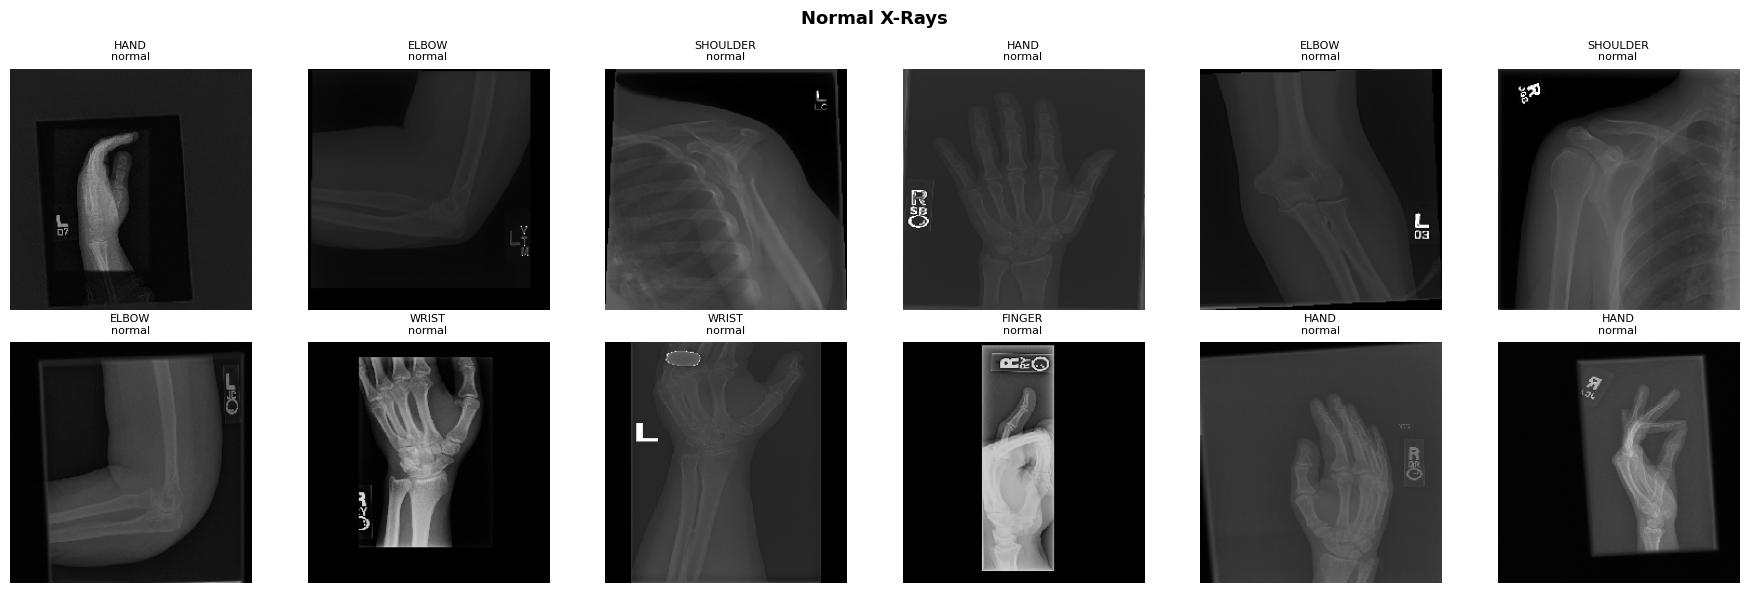

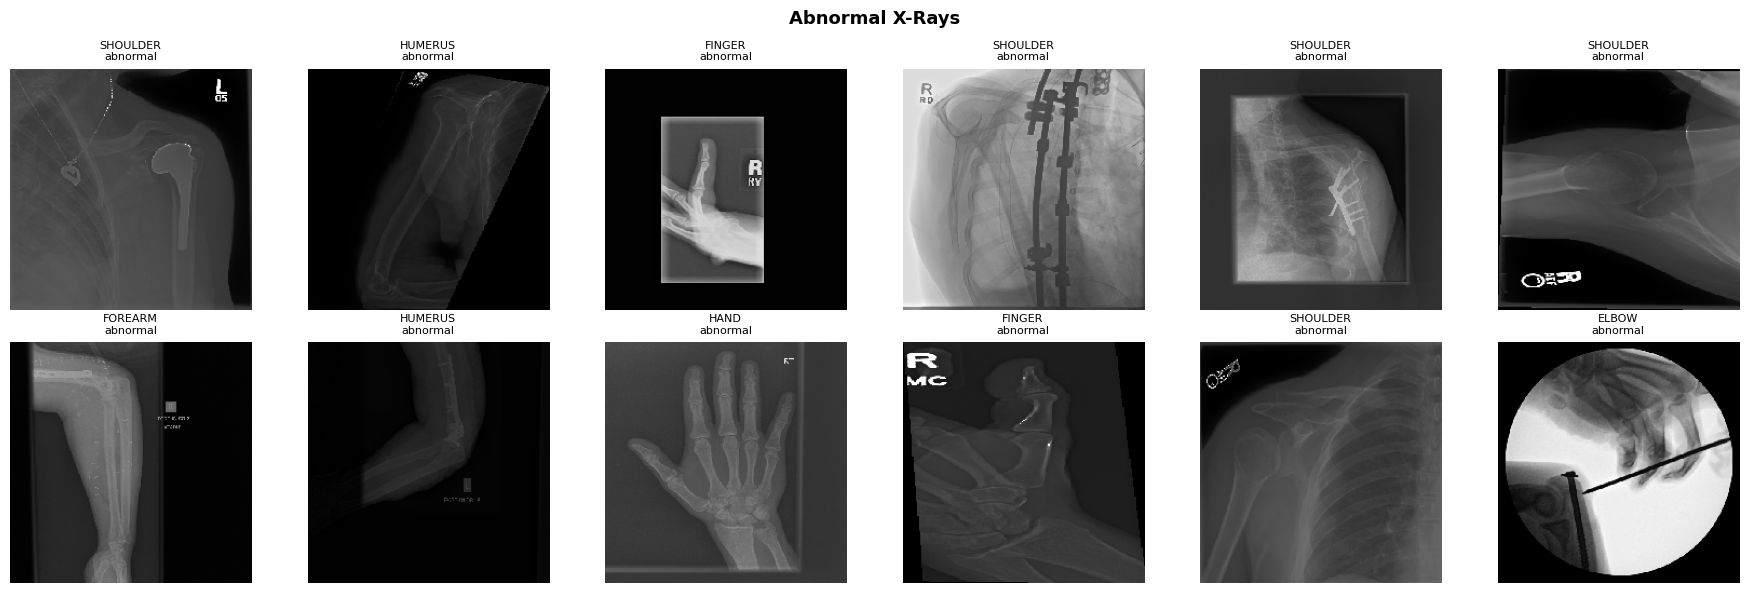

In [6]:
def show_samples(dataframe, title=''):
    sample = dataframe.sample(12, random_state=42)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = load_img(row['image_path'], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f"{row['category'].replace('XR_', '')}\n{row['label_type']}", fontsize=8)
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(df[df['label_type'] == 'normal'],   title='Normal X-Rays')
show_samples(df[df['label_type'] == 'abnormal'], title='Abnormal X-Rays')

---
## Data Generators

We use Keras `ImageDataGenerator` to:
- Load images from disk in batches (avoids loading 40k images into RAM at once)
- Apply **data augmentation** on training images (random flips, rotations, zooms) to make the model more robust
- Scale pixel values from [0, 255] to [0, 1]

In [7]:
df_train = df[df['set_type'] == 'train'].reset_index(drop=True)
df_valid = df[df['set_type'] == 'valid'].reset_index(drop=True)

# Simple but aggressive class weights — abnormal gets 2x penalty
# This helps the model not ignore the minority class
class_weight = {
    0: 1.0,   # normal
    1: 2.0,   # abnormal
}
print('Class weights:', class_weight)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.05,
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'],
    shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'],
    shuffle=False
)

print(f'Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}')

Class weights: {0: 1.0, 1: 2.0}
Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.
Train batches: 576  |  Val batches: 50


---
## Helper Functions

Reusable functions for plotting and evaluating — shared across all models.

In [8]:
def plot_history(history, model_name=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History - {model_name}', fontsize=13, fontweight='bold')
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],          label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Validation')
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate(model, generator, model_name=''):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'{model_name} - Loss: {loss:.4f} | Accuracy: {acc:.4f}')
    return loss, acc


def plot_confusion_matrix(model, generator, model_name=''):
    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    labels = list(generator.class_indices.keys())
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))


def show_misclassified(model, generator, model_name=''):
    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    labels = list(generator.class_indices.keys())
    wrong  = np.where(y_pred != y_true)[0]
    sample = np.random.choice(wrong, min(12, len(wrong)), replace=False)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, idx in zip(axes.flat, sample):
        img = load_img(generator.filenames[idx], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f"True: {labels[y_true[idx]]}\nPred: {labels[y_pred[idx]]}", fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle(f'Misclassified - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Total wrong: {len(wrong)} / {len(y_true)}')

In [9]:
def make_dataset(df, preprocess_fn, augment=False):
    """
    Build a fast tf.data pipeline.
    Used in Phase 2 of transfer learning — much faster than ImageDataGenerator
    because images are loaded in parallel on CPU while the GPU trains.
    """
    paths  = df['image_path'].values
    labels = df['label_type'].map({'normal': 0.0, 'abnormal': 1.0}).values

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = preprocess_fn(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


# Results table — one row per model, filled in as each model finishes
results_df = pd.DataFrame(columns=[
    'model', 'val_loss', 'val_accuracy',
    'precision_normal', 'recall_normal', 'f1_normal',
    'precision_abnormal', 'recall_abnormal', 'f1_abnormal',
    'epochs_trained'
])

def log_results(model, generator, model_name, history=None):
    """Evaluate model on generator and append a summary row to results_df."""
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)

    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    report = classification_report(y_true, y_pred,
                                   target_names=list(generator.class_indices.keys()),
                                   output_dict=True)
    global results_df
    results_df = pd.concat([results_df, pd.DataFrame([{
        'model':              model_name,
        'val_loss':           round(loss, 4),
        'val_accuracy':       round(acc, 4),
        'precision_normal':   round(report['normal']['precision'], 4),
        'recall_normal':      round(report['normal']['recall'], 4),
        'f1_normal':          round(report['normal']['f1-score'], 4),
        'precision_abnormal': round(report['abnormal']['precision'], 4),
        'recall_abnormal':    round(report['abnormal']['recall'], 4),
        'f1_abnormal':        round(report['abnormal']['f1-score'], 4),
        'epochs_trained':     len(history.history['val_loss']) if history else None,
    }])], ignore_index=True)
    print(f'Logged: {model_name}')
    display(results_df)

---
## Model 3 - EfficientNetB0 (Transfer Learning)

A second pre-trained model for comparison with DenseNet121.

**What makes EfficientNet different?**  
Traditional CNNs scale by going deeper OR wider. EfficientNet uses **compound scaling** — it scales depth, width, and image resolution together in a balanced ratio, achieving better accuracy with fewer parameters.

**Why compare it to DenseNet?**  
DenseNet was specifically tested on MURA. EfficientNet is a more general modern architecture. Comparing them lets us see whether the task benefits from a medically-motivated design.

Same two-phase training approach as DenseNet121.

In [10]:
# Switch back to full precision for EfficientNetB0
# mixed_float16 can destabilise fine-tuning of pretrained models
mixed_precision.set_global_policy('float32')

# EfficientNet also has its own preprocessing - different from DenseNet's
eff_train_datagen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    horizontal_flip=True, rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1,
    brightness_range=[0.8, 1.2], shear_range=0.05,
)
eff_val_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=True, seed=42
)
eff_val_gen = eff_val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=False
)

Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.


In [11]:
eff_base  = EfficientNetB0(include_top=False, weights='imagenet',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')

x       = Dense(256, activation='relu',
                kernel_regularizer=tf.keras.regularizers.l2(1e-4))(eff_base.output)
x       = Dropout(0.5)(x)
eff_out = Dense(1, activation='sigmoid')(x)
eff_model = Model(inputs=eff_base.input, outputs=eff_out)

# Phase 1: freeze entire base — only the new head trains
for layer in eff_base.layers:
    layer.trainable = False

eff_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

print('Phase 1: training the head (base frozen) ...')
eff_p1 = eff_model.fit(
    eff_train_gen, validation_data=eff_val_gen,
    epochs=10, callbacks=[es], class_weight=class_weight, verbose=1
)
print(f'Phase 1 done ({len(eff_p1.history["loss"])} epochs)')

I0000 00:00:1773500825.224403     151 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Phase 1: training the head (base frozen) ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1773500843.979650     212 service.cc:152] XLA service 0x7ca7ac002dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773500843.979690     212 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773500846.877599     212 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773500860.418524     212 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


576/576 ━━━━━━━━━━━━━━━━━━━━ 1067s 2s/step - accuracy: 0.6152 - loss: 0.9076 - val_accuracy: 0.7379 - val_loss: 0.5653
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 731s 1s/step - accuracy: 0.6776 - loss: 0.8201 - val_accuracy: 0.7294 - val_loss: 0.5605
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.6921 - loss: 0.8037 - val_accuracy: 0.7291 - val_loss: 0.5666
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 711s 1s/step - accuracy: 0.6957 - loss: 0.7926 - val_accuracy: 0.7460 - val_loss: 0.5531
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - accuracy: 0.6974 - loss: 0.7925 - val_accuracy: 0.7354 - val_loss: 0.5622
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - accuracy: 0.7085 - loss: 0.7751 - val_accuracy: 0.7604 - val_loss: 0.5399
Epoch 7/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.7047 - loss: 0.7827 - val_accuracy: 0.7516 - val_loss: 0.5446
Epoch 8/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.7086 - loss: 0.7751 - val_accuracy: 0.74

Phase 2: fine-tuning last 30 layers with cosine LR decay ...
Epoch 1/30


2026-03-14 17:11:10.139691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:11:10.352214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:11:10.841937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:11:11.052093: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:11:11.263400: E external/local_xla/xla/stream_

575/576 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6494 - loss: 0.9452

2026-03-14 17:12:45.367868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:12:45.575981: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:12:45.780916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6495 - loss: 0.9450
Epoch 1: val_accuracy improved from -inf to 0.69346, saving model to /kaggle/working/eff_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 149s 195ms/step - accuracy: 0.6495 - loss: 0.9449 - val_accuracy: 0.6935 - val_loss: 0.6507
Epoch 2/30
575/576 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5887 - loss: 1.0615
Epoch 2: val_accuracy improved from 0.69346 to 0.70222, saving model to /kaggle/working/eff_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 87s 145ms/step - accuracy: 0.5890 - loss: 1.0609 - val_accuracy: 0.7022 - val_loss: 0.6386
Epoch 3/30
575/576 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6202 - loss: 0.9668
Epoch 3: val_accuracy did not improve from 0.70222
576/576 ━━━━━━━━━━━━━━━━━━━━ 85s 141ms/step - accuracy: 0.6204 - loss: 0.9663 - val_accuracy: 0.6978 - val_loss: 0.6584
Epoch 4/30
575/576 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6436 - loss: 0.9179
Epoch 4: val_accuracy improved from 0.70222 

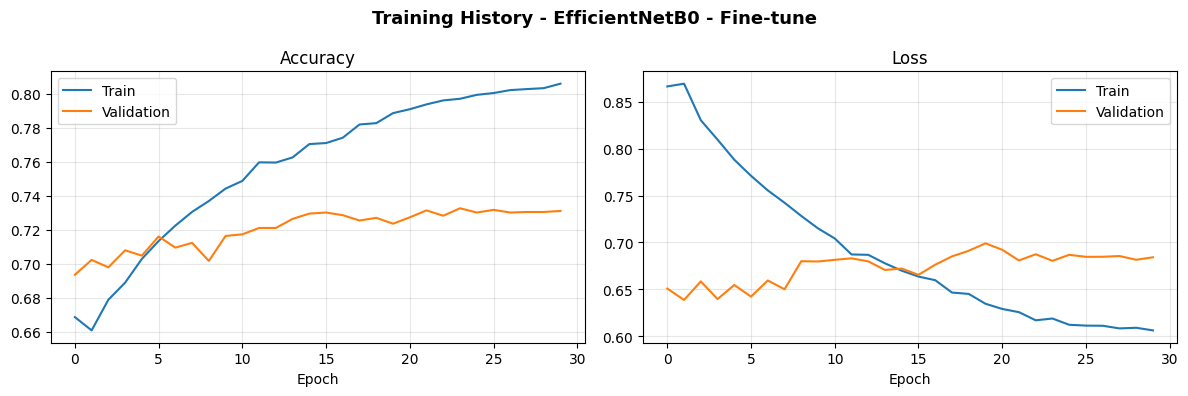

EfficientNetB0 - Loss: 0.6135 | Accuracy: 0.7398


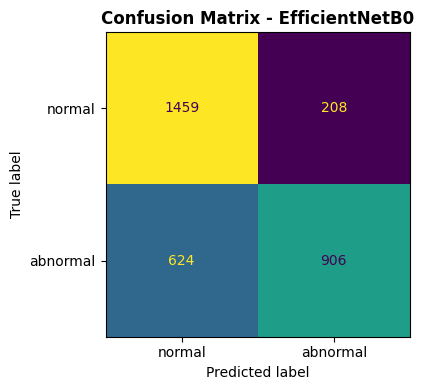

              precision    recall  f1-score   support

      normal       0.70      0.88      0.78      1667
    abnormal       0.81      0.59      0.69      1530

    accuracy                           0.74      3197
   macro avg       0.76      0.73      0.73      3197
weighted avg       0.75      0.74      0.73      3197



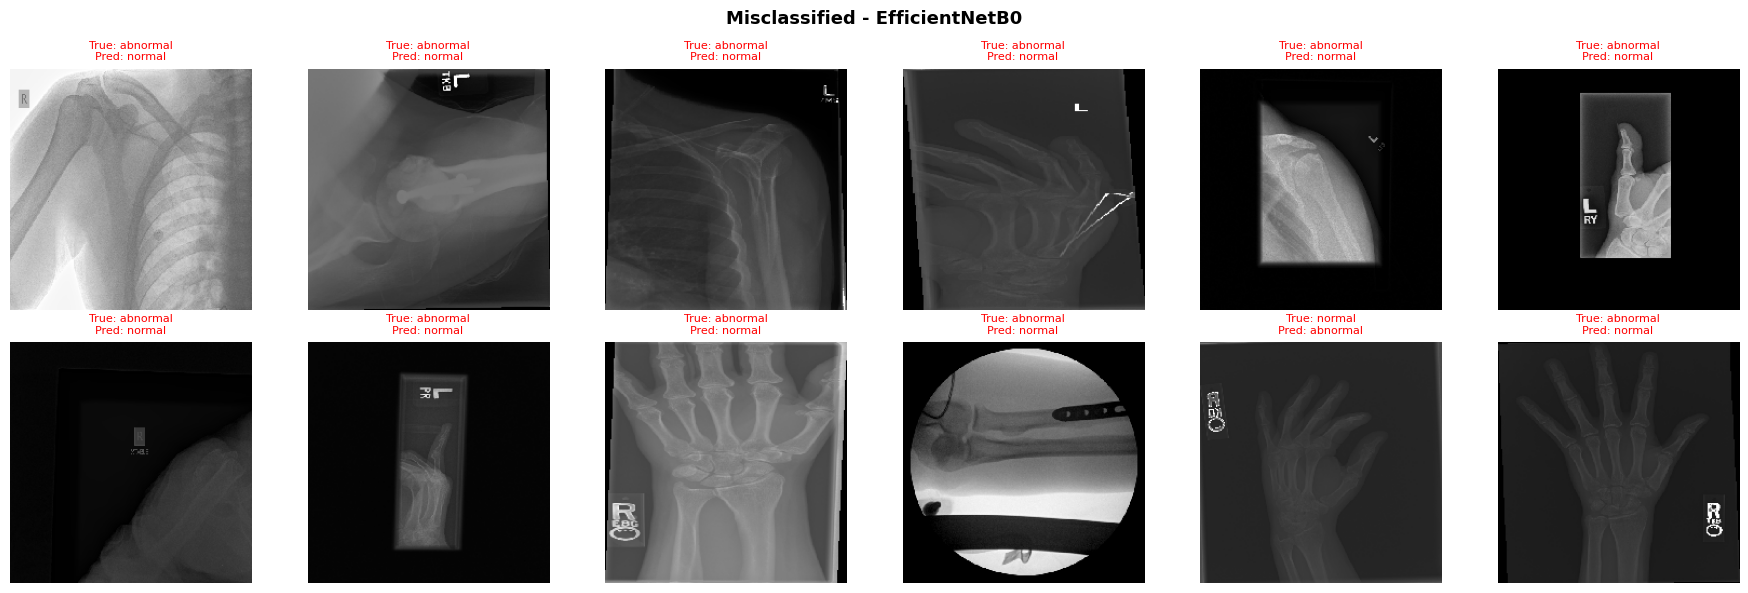

Total wrong: 832 / 3197
Logged: EfficientNetB0


/tmp/ipykernel_151/2417869877.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([{


,model,val_loss,val_accuracy,precision_normal,recall_normal,f1_normal,precision_abnormal,recall_abnormal,f1_abnormal,epochs_trained
0,EfficientNetB0,0.6135,0.7398,0.7004,0.8752,0.7781,0.8133,0.5922,0.6853,30


In [12]:
# Phase 2: unfreeze only the last 30 layers of EfficientNetB0
for layer in eff_base.layers[:-30]:
    layer.trainable = False
for layer in eff_base.layers[-30:]:
    layer.trainable = True

total_steps = (len(df_train) // BATCH_SIZE) * EPOCHS
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-5,
    decay_steps=total_steps,
    alpha=1e-7,
)

# Save to /kaggle/working on Kaggle, /content on Colab
SAVE_DIR = '/kaggle/working' if os.path.exists('/kaggle/input') else '/content'

eff_model.compile(optimizer=Adam(lr_schedule), loss='binary_crossentropy', metrics=['accuracy'])
es         = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(f'{SAVE_DIR}/eff_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

eff_train_ds = make_dataset(df_train, eff_preprocess, augment=True)
eff_val_ds   = make_dataset(df_valid, eff_preprocess)

print('Phase 2: fine-tuning last 30 layers with cosine LR decay ...')
eff_p2 = eff_model.fit(
    eff_train_ds, validation_data=eff_val_ds,
    epochs=EPOCHS, callbacks=[es, checkpoint],
    class_weight=class_weight, verbose=1
)
print(f'Phase 2 done ({len(eff_p2.history["loss"])} epochs)')

plot_history(eff_p2, model_name='EfficientNetB0 - Fine-tune')
eff_eval = evaluate(eff_model, eff_val_gen, model_name='EfficientNetB0')
plot_confusion_matrix(eff_model, eff_val_gen, model_name='EfficientNetB0')
show_misclassified(eff_model, eff_val_gen, model_name='EfficientNetB0')
log_results(eff_model, eff_val_gen, model_name='EfficientNetB0', history=eff_p2)

---
## Model 4 - Dual-Backbone Fusion (MobileNetV2 + EfficientNetB0)

An ensemble-style architecture that runs **two pretrained backbones in parallel** on the same image and combines their features before making a decision.

**Why two backbones?**  
Each backbone extracts different feature representations from the same X-ray. MobileNetV2 uses inverted residuals and linear bottlenecks, while EfficientNetB0 uses compound scaling. Combining them gives the classifier a richer, more diverse feature set than either alone.

### How it works

```
Input image (224 x 224 x 3)
       |              |
MobileNetV2      EfficientNetB0
(frozen)          (frozen)
    |                  |
GlobalAvgPool    GlobalAvgPool
 → 1280-dim       → 1280-dim
       |              |
     Concatenate (2560-dim)
          |
     BatchNorm
     Dense(256) → Dropout(0.4)
     Dense(1, sigmoid)
```

**Two-phase training:**
- **Phase 1** — both backbones frozen, only the fusion head trains
- **Phase 2** — last 30 layers of each backbone unfrozen, full fine-tune with cosine LR decay

In [13]:
mixed_precision.set_global_policy('float32')

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# Separate generators for the dual-backbone model
# Each backbone needs its own preprocessing function
dual_train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: (eff_preprocess(x) + mobilenet_preprocess(x)) / 2,
    horizontal_flip=True, rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1,
    brightness_range=[0.8, 1.2], shear_range=0.05,
)
dual_val_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: (eff_preprocess(x) + mobilenet_preprocess(x)) / 2
)

dual_train_gen = dual_train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=True, seed=42
)
dual_val_gen = dual_val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=False
)

print(f'Train batches: {len(dual_train_gen)}  |  Val batches: {len(dual_val_gen)}')

Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.
Train batches: 576  |  Val batches: 50


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2560)      │          0 │ mobilenetv2_1.00… │
│ (Concatenate)       │                   │            │ efficientnetb0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2560)      │     10,240 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    655,616 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,973,668 (26.60 MB)

 Trainable params: 660,993 (2.52 MB)

 Non-trainable params: 6,312,675 (24.08 MB)

Phase 1: training fusion head (both backbones frozen) ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 803s 1s/step - accuracy: 0.6173 - loss: 1.0980 - val_accuracy: 0.7410 - val_loss: 0.5873
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 819s 1s/step - accuracy: 0.6694 - loss: 0.8444 - val_accuracy: 0.7438 - val_loss: 0.5733
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.6878 - loss: 0.8151 - val_accuracy: 0.7338 - val_loss: 0.5818
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 715s 1s/step - accuracy: 0.6942 - loss: 0.8022 - val_accuracy: 0.7247 - val_loss: 0.5767
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 702s 1s/step - accuracy: 0.6968 - loss: 0.7994 - val_accuracy: 0.7354 - val_loss: 0.5720
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 698s 1s/step - accuracy: 0.7023 - loss: 0.7905 - val_accuracy: 0.7448 - val_loss: 0.5694
Epoch 7/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 678s 1s/step - accuracy: 0.7076 - loss: 0.7912 - val_accuracy: 0.7535 - val_loss: 0.5677
Epoch 8/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 773s 1s/step - accuracy: 0.7133 - loss: 0.7857 - val_accu

2026-03-14 19:59:11.796804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 19:59:11.995000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6991 - loss: 0.8155
Epoch 1: val_accuracy improved from -inf to 0.71692, saving model to /kaggle/working/dual_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.6992 - loss: 0.8154 - val_accuracy: 0.7169 - val_loss: 0.6367
Epoch 2/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7399 - loss: 0.7572
Epoch 2: val_accuracy improved from 0.71692 to 0.75540, saving model to /kaggle/working/dual_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - accuracy: 0.7399 - loss: 0.7571 - val_accuracy: 0.7554 - val_loss: 0.5906
Epoch 3/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7530 - loss: 0.7303
Epoch 3: val_accuracy improved from 0.75540 to 0.77510, saving model to /kaggle/working/dual_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.7530 - loss: 0.7303 - val_accuracy: 0.7751 - val_loss: 0.5485
Epoch 4/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7637 - loss: 0.7050
Epoch 4:

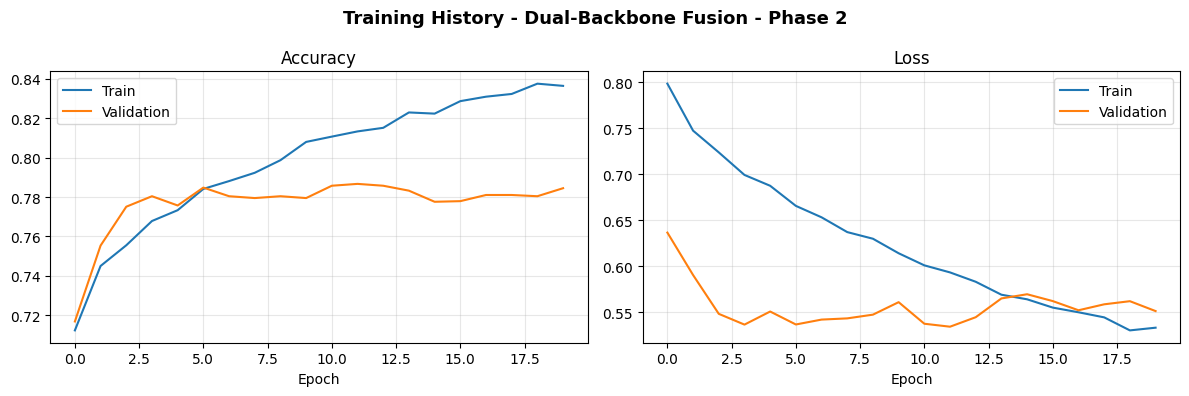

Dual-Backbone Fusion - Loss: 0.5345 | Accuracy: 0.7867


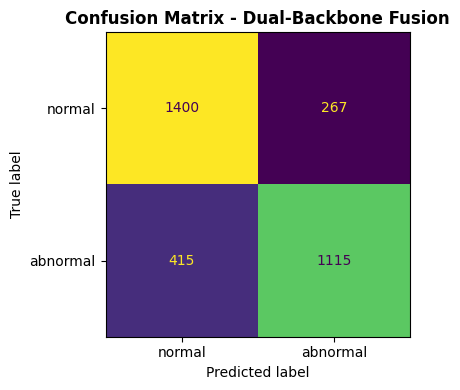

              precision    recall  f1-score   support

      normal       0.77      0.84      0.80      1667
    abnormal       0.81      0.73      0.77      1530

    accuracy                           0.79      3197
   macro avg       0.79      0.78      0.78      3197
weighted avg       0.79      0.79      0.79      3197



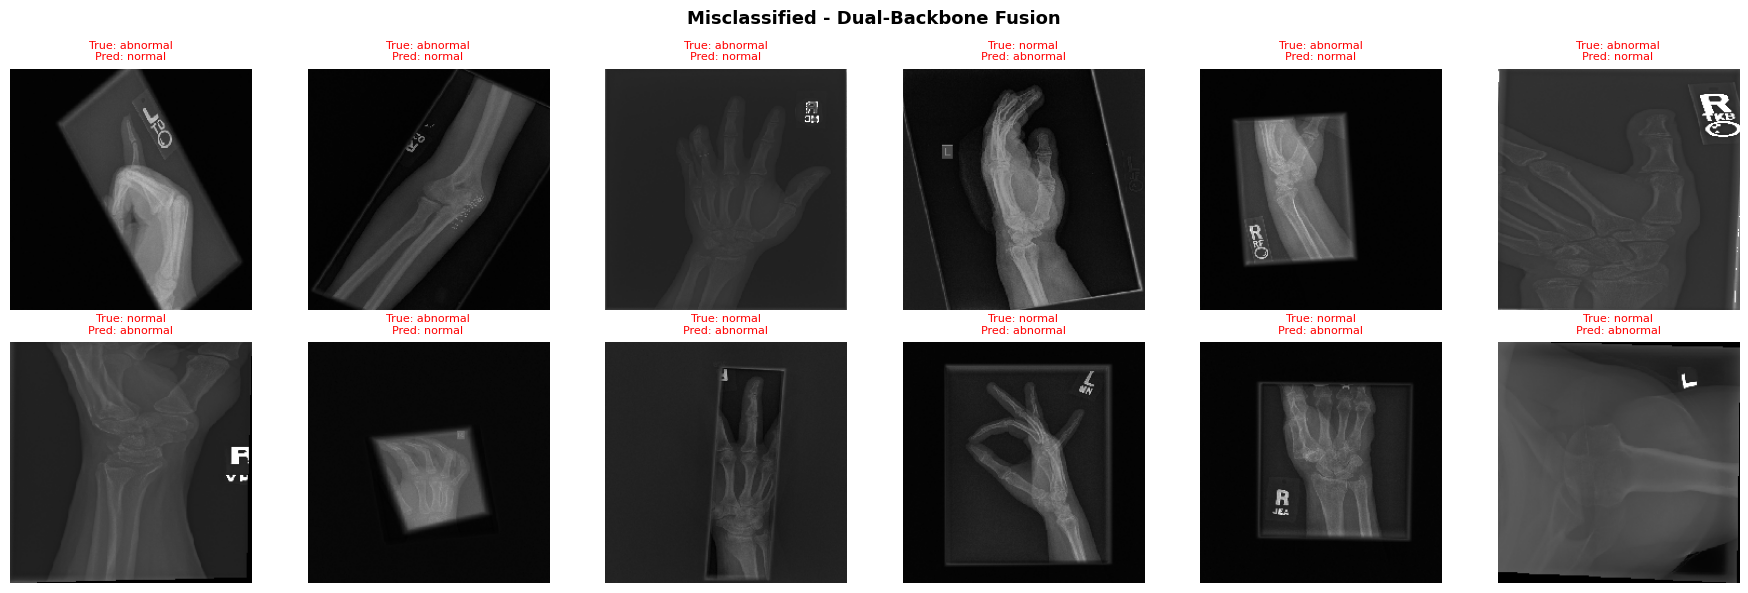

Total wrong: 682 / 3197


In [14]:
def build_dual_backbone():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Branch A: MobileNetV2
    mob_base = MobileNetV2(include_top=False, weights='imagenet',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    mob_base.trainable = False
    mob_out = mob_base(inp)   # (None, 1280)

    # Branch B: EfficientNetB0
    eff_base2 = EfficientNetB0(include_top=False, weights='imagenet',
                               input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    eff_base2.trainable = False
    eff_out = eff_base2(inp)  # (None, 1280)

    # Fuse both feature vectors
    x = tf.keras.layers.Concatenate()([mob_out, eff_out])  # (None, 2560)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=inp, outputs=out), mob_base, eff_base2


dual_model, mob_base, eff_base2 = build_dual_backbone()
dual_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
dual_model.summary()

# Phase 1: both backbones frozen — only the fusion head trains
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

print('Phase 1: training fusion head (both backbones frozen) ...')
dual_p1 = dual_model.fit(
    dual_train_gen, validation_data=dual_val_gen,
    epochs=10, callbacks=[es], class_weight=class_weight, verbose=1
)
print(f'Phase 1 done ({len(dual_p1.history["loss"])} epochs)')

# Phase 2: unfreeze last 30 layers of each backbone + fine-tune
for layer in mob_base.layers[:-30]:
    layer.trainable = False
for layer in mob_base.layers[-30:]:
    layer.trainable = True
for layer in eff_base2.layers[:-30]:
    layer.trainable = False
for layer in eff_base2.layers[-30:]:
    layer.trainable = True

print(f'MobileNetV2:    {sum(1 for l in mob_base.layers  if l.trainable)} layers unfrozen')
print(f'EfficientNetB0: {sum(1 for l in eff_base2.layers if l.trainable)} layers unfrozen')

total_steps = len(dual_train_gen) * EPOCHS
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-5, decay_steps=total_steps, alpha=1e-7,
)

SAVE_DIR = '/kaggle/working' if os.path.exists('/kaggle/input') else '/content'

dual_model.compile(optimizer=Adam(lr_schedule), loss='binary_crossentropy', metrics=['accuracy'])
es         = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(f'{SAVE_DIR}/dual_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

print('Phase 2: fine-tuning last 30 layers of each backbone ...')
dual_p2 = dual_model.fit(
    dual_train_gen, validation_data=dual_val_gen,
    epochs=EPOCHS, callbacks=[es, checkpoint],
    class_weight=class_weight, verbose=1
)
print(f'Phase 2 done ({len(dual_p2.history["loss"])} epochs)')

plot_history(dual_p2, model_name='Dual-Backbone Fusion - Phase 2')
dual_eval = evaluate(dual_model, dual_val_gen, model_name='Dual-Backbone Fusion')
plot_confusion_matrix(dual_model, dual_val_gen, model_name='Dual-Backbone Fusion')
show_misclassified(dual_model, dual_val_gen, model_name='Dual-Backbone Fusion')

---
## Final Comparison

The 2 models evaluated on the same MURA validation set.

In [15]:
print(f"{'Model':<45} {'Val Accuracy':>14} {'Val Loss':>12}")
print('-' * 73)
for name, (loss, acc) in [
    ('EfficientNetB0 (transfer learning)',        eff_eval),
    ('Dual-Backbone Fusion (MobileNetV2 + Eff)',  dual_eval),
]:
    print(f'{name:<45} {acc:>14.4f} {loss:>12.4f}')

Model                                           Val Accuracy     Val Loss
-------------------------------------------------------------------------
EfficientNetB0 (transfer learning)                    0.7398       0.6135
Dual-Backbone Fusion (MobileNetV2 + Eff)              0.7867       0.5345
